In [35]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [1]:
!kaggle datasets download -d anthonytherrien/dog-vs-cat

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat
License(s): CC-BY-SA-4.0
100% 360M/360M [00:04<00:00, 93.0MB/s]



In [3]:
import zipfile
zip_ref=zipfile.ZipFile("/content/dog-vs-cat.zip","r")
zip_ref.extractall("/content")
zip_ref.close()

In [4]:
from tensorflow.keras.utils import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(256, 256),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(256, 256),
    batch_size=32
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [5]:
import os
import random
import shutil

# Paths
source_dir = "/content/animals"
output_dir = "/content/dataset"

classes = ["cat", "dog"]
split_ratio = 0.8

# Create folders
for split in ["train", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

# Split and copy images
for cls in classes:
    class_path = os.path.join(source_dir, cls)

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy training images
    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "train", cls, img)
        )

    # Copy testing images
    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(output_dir, "test", cls, img)
        )

print("Dataset split completed successfully!")

Dataset split completed successfully!


In [6]:
import os

print("Train Cats:", len(os.listdir("/content/dataset/train/cat")))
print("Train Dogs:", len(os.listdir("/content/dataset/train/dog")))

print("Test Cats:", len(os.listdir("/content/dataset/test/cat")))
print("Test Dogs:", len(os.listdir("/content/dataset/test/dog")))

Train Cats: 400
Train Dogs: 400
Test Cats: 100
Test Dogs: 100


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,BatchNormalization,Dropout
from tensorflow.keras.utils import save_img


In [8]:
import tensorflow

train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/dataset/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/dataset/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 800 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


In [9]:
from tensorflow import keras

data_gen = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(
        height_factor=0.2,
        width_factor=0.2
    )
])

In [10]:
import os
os.makedirs("augmented_dataset", exist_ok=True)

for class_name in train_ds.class_names:
    os.makedirs(
        os.path.join("augmented_dataset", class_name),
        exist_ok=True
    )
count = 0

for images, labels in train_ds:

    for version in range(5):

        augmented_images = data_gen(
            images,
            training=True
        )

        for i in range(images.shape[0]):

            class_name = train_ds.class_names[
                labels[i].numpy()
            ]

            save_img(
                os.path.join(
                "augmented_dataset",
                class_name,
                f"aug_{count}_v{version}.jpg") ,
                augmented_images[i]
            )

            count += 1

In [11]:
import os

cat_count = len(os.listdir("augmented_dataset/cat"))
dog_count = len(os.listdir("augmented_dataset/dog"))

print("Cat images:", cat_count)
print("Dog images:", dog_count)
print("Total images:", cat_count + dog_count)

Cat images: 2000
Dog images: 2000
Total images: 4000


In [12]:
def process(image, label):
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D
from tensorflow.keras.regularizers import l2

model2 = Sequential()

model2.add(Conv2D(
    32,
    kernel_size=(3,3),
    padding="valid",
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.001),
    input_shape=(256,256,3)
))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(
    pool_size=(2,2),
    strides=(2,2),
    padding="valid"
))

model2.add(Conv2D(
    64,
    kernel_size=(3,3),
    padding="valid",
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.001)
))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(
    pool_size=(2,2),
    strides=(2,2),
    padding="valid"
))

model2.add(Conv2D(
    128,
    kernel_size=(3,3),
    padding="valid",
    activation="relu",
    kernel_initializer="he_normal",
    kernel_regularizer=l2(0.001)
))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(
    pool_size=(2,2),
    strides=(2,2),
    padding="valid"
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model2.add(Flatten())


In [15]:

model2.add(Dense(128,activation="relu"))
model2.add(Dropout(0.3))

model2.add(Dense(64,activation="relu"))
model2.add(Dropout(0.3))
model2.add(Dense(1,activation="sigmoid"))

In [16]:
model2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
history=model2.fit(train_ds,validation_data=validation_ds,epochs=10    )

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 373ms/step - accuracy: 0.7025 - loss: 6.5717 - val_accuracy: 0.5050 - val_loss: 16.4374
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.7775 - loss: 2.9678 - val_accuracy: 0.5000 - val_loss: 10.3161
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 302ms/step - accuracy: 0.8550 - loss: 1.6366 - val_accuracy: 0.5050 - val_loss: 10.2165
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.8650 - loss: 1.4084 - val_accuracy: 0.6850 - val_loss: 3.5217
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 304ms/step - accuracy: 0.9050 - loss: 1.0389 - val_accuracy: 0.7800 - val_loss: 2.5068
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.9137 - loss: 0.9445 - val_accuracy: 0.7200 - val_loss: 4.9281
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 299ms/step - accuracy: 0.9575 - loss: 0.8562 - val_accuracy: 0.7650 - val_loss: 3.2582
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 261ms/step - accuracy: 0.9563 - loss: 0.7118 - val_accuracy

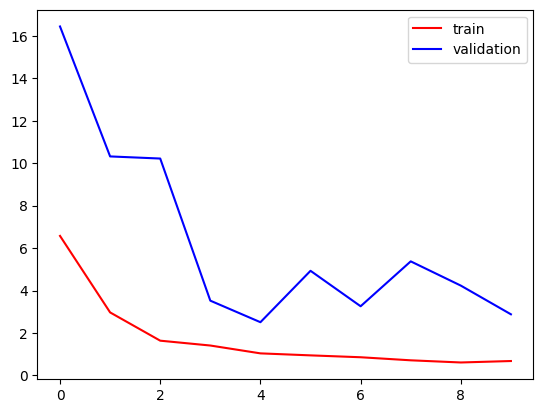

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],color="red",label="train")
plt.plot(history.history["val_loss"],color="blue",label="validation")
plt.legend()
plt.show()

In [24]:
import matplotlib.pyplot as plt


In [25]:
from tensorflow.keras.utils import load_img, img_to_array

In [27]:
loading=load_img("/content/dataset/test/cat/00001-4122619874.png",target_size=(256,256))


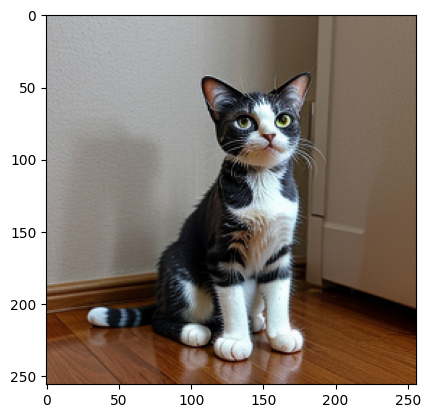

In [28]:
plt.imshow(loading)

In [32]:
import numpy as np
from tensorflow.keras.utils import img_to_array
img_array=img_to_array(loading)
img_array=img_array/255.0
img_array = np.expand_dims(img_array, axis=0)

In [33]:
prediction=model2.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 999ms/step


In [34]:
if prediction > 0.5:
  print("it is a dog")
else :
  print("it is a cat")

it is a cat
